In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [98]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Blues_d')


In [99]:
pd.set_option('display.max_columns', None)

In [100]:
print("Libraries loaded!")


Libraries loaded!


In [101]:
orders      = pd.read_csv('/Users/bulbulrajput/Desktop/data/olist_orders_dataset.csv')
customers   = pd.read_csv('/Users/bulbulrajput/Desktop/data/olist_customers_dataset.csv')
items       = pd.read_csv('/Users/bulbulrajput/Desktop/data/olist_order_items_dataset.csv')
products    = pd.read_csv('/Users/bulbulrajput/Desktop/data/olist_products_dataset.csv')
sellers     = pd.read_csv('/Users/bulbulrajput/Desktop/data/olist_sellers_dataset.csv')
payments    = pd.read_csv('/Users/bulbulrajput/Desktop/data/olist_order_payments_dataset.csv')
reviews     = pd.read_csv('/Users/bulbulrajput/Desktop/data/olist_order_reviews_dataset.csv')
geolocation = pd.read_csv('/Users/bulbulrajput/Desktop/data/olist_geolocation_dataset.csv')
translation = pd.read_csv('/Users/bulbulrajput/Desktop/data/product_category_name_translation.csv')


In [102]:
print("All datasets loaded!")
print(f"Orders: {orders.shape}")
print(f"Customers: {customers.shape}")
print(f"Items: {items.shape}")
print(f"Products: {products.shape}")
print(f"Payments: {payments.shape}")
print(f"Reviews: {reviews.shape}")

All datasets loaded!
Orders: (99441, 8)
Customers: (99441, 5)
Items: (112650, 7)
Products: (32951, 9)
Payments: (103886, 5)
Reviews: (99224, 7)


In [103]:
# Run this on each table — takes 2 minutes but saves hours later
for name, df in [('orders', orders), ('customers', customers),
                 ('items', items), ('products', products),
                 ('payments', payments), ('reviews', reviews)]:
    print(f"\n{'='*40}")
    print(f"TABLE: {name.upper()}")
    print(f"Shape: {df.shape}")
    print(f"Nulls:\n{df.isnull().sum()[df.isnull().sum() > 0]}")


TABLE: ORDERS
Shape: (99441, 8)
Nulls:
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

TABLE: CUSTOMERS
Shape: (99441, 5)
Nulls:
Series([], dtype: int64)

TABLE: ITEMS
Shape: (112650, 7)
Nulls:
Series([], dtype: int64)

TABLE: PRODUCTS
Shape: (32951, 9)
Nulls:
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

TABLE: PAYMENTS
Shape: (103886, 5)
Nulls:
Series([], dtype: int64)

TABLE: REVIEWS
Shape: (99224, 7)
Nulls:
review_comment_title      87656
review_comment_message    58247
dtype: int64


In [104]:
df = pd.merge(orders, customers, on='customer_id', how='left')

In [105]:
df = pd.merge(df, items, on='order_id', how='left')

In [106]:
df = pd.merge(df, products, on='product_id', how='left')

In [107]:
df = pd.merge(df, translation, on='product_category_name', how='left')

In [108]:
df = pd.merge(df, payments[['order_id','payment_value']],
              on='order_id', how='left')

In [109]:
df = pd.merge(df, reviews[['order_id','review_score']],
              on='order_id', how='left')

In [110]:
print(f"Master dataframe shape: {df.shape}")
df.head()

Master dataframe shape: (119143, 29)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,payment_value,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares,18.12,4.0
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares,2.00,4.0
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares,18.59,4.0
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery,141.46,4.0
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto,179.12,5.0


In [111]:
date_cols = ['order_purchase_timestamp',
             'order_delivered_customer_date',
             'order_estimated_delivery_date']

In [112]:
for col in date_cols:
    df[col] = pd.to_datetime(df[col])

In [113]:
df['order_month']     = df['order_purchase_timestamp'].dt.to_period('M')
df['order_year']      = df['order_purchase_timestamp'].dt.year
df['delivery_days']   = (df['order_delivered_customer_date'] -
                          df['order_purchase_timestamp']).dt.days
df['late_delivery']   = df['order_delivered_customer_date'] > \
                         df['order_estimated_delivery_date']


In [114]:
print("Date features created!")
df[['order_month','delivery_days','late_delivery']].head()

Date features created!


,order_month,delivery_days,late_delivery
0,2017-10,8.0,False
1,2017-10,8.0,False
2,2017-10,8.0,False
3,2018-07,13.0,False
4,2018-08,9.0,False


In [115]:
import os
os.makedirs('data', exist_ok=True)
os.makedirs('charts', exist_ok=True)
print("Folders created!")
print("Working directory:", os.getcwd())

Folders created!
Working directory: /Users/bulbulrajput/Desktop/ecommerce-sales-analysis


In [116]:
df.to_csv('data/master_df.csv', index=False)
print(f"Master dataset saved — {df.shape[0]:,} rows, {df.shape[1]} columns")

Master dataset saved — 119,143 rows, 33 columns


In [117]:
# Data cleaning 
print("Shape before cleaning:", df.shape)
print("\nNull counts:\n", df.isnull().sum()[df.isnull().sum() > 0])

Shape before cleaning: (119143, 33)

Null counts:
 order_approved_at                 177
order_delivered_carrier_date     2086
order_delivered_customer_date    3421
order_item_id                     833
product_id                        833
seller_id                         833
shipping_limit_date               833
price                             833
freight_value                     833
product_category_name            2542
product_name_lenght              2542
product_description_lenght       2542
product_photos_qty               2542
product_weight_g                  853
product_length_cm                 853
product_height_cm                 853
product_width_cm                  853
product_category_name_english    2567
payment_value                       3
review_score                      997
delivery_days                    3421
dtype: int64


In [118]:
# Drop rows where essential columns are null
df.dropna(subset=['order_id', 'customer_id', 'payment_value'], inplace=True)

# Fix for FutureWarning — assign directly instead of inplace
df['review_score'] = df['review_score'].fillna(df['review_score'].median())
df['product_category_name_english'] = df['product_category_name_english'].fillna('Unknown').copy()

# Drop rows where delivery days is negative (data error)
df = df[df['delivery_days'] >= 0].copy()

# Remove duplicates
df = df.drop_duplicates(subset=['order_id', 'product_id']).copy()

print("\nShape after cleaning:", df.shape)
print("Cleaning done!")


Shape after cleaning: (100194, 33)
Cleaning done!


In [119]:
#Business Summary 
print("=" * 45)
print("       OLIST BUSINESS SUMMARY")
print("=" *45)
print(f"Total Orders:   {df['order_id'].nunique():,}")
print(f"Total Customers:   {df['customer_id'].nunique():,}")
print(f"Total Revenue:     R$ {df['payment_value'].sum():,.2f}")
print(f"Avg order Value:   R$ {df['payment_value'].mean():,.2f}")
print(f"Avg delivery days:   {df['delivery_days'].mean():.1f} days")
print(f"Late Delivery Rate:   {df['late_delivery'].mean()*100:.1f}%")
print(f"Avg Review Score:     {df['review_score'].mean():.2f} / 5")
print('=' * 45)





       OLIST BUSINESS SUMMARY
Total Orders:   96,475
Total Customers:   96,475
Total Revenue:     R$ 16,133,204.75
Avg order Value:   R$ 161.02
Avg delivery days:   12.0 days
Late Delivery Rate:   8.0%
Avg Review Score:     4.13 / 5


In [120]:
#Monthly Revenue 

monthly = df.groupby('order_month').agg(
    revenue  =('payment_value', 'sum'),
    orders =('order_id', 'nunique'),
    avg_order =('payment_value', 'mean')
).reset_index()

monthly['order_month'] =monthly['order_month'].astype(str)
print(monthly.tail(10))

   order_month     revenue  orders   avg_order
12     2017-11  1226247.28    7288  161.030503
13     2017-12   874429.38    5513  153.113182
14     2018-01  1131251.07    7069  153.660835
15     2018-02   996467.60    6556  147.975587
16     2018-03  1158433.76    7003  160.225970
17     2018-04  1196713.34    6798  168.741306
18     2018-05  1204321.39    6749  171.800484
19     2018-06  1049396.29    6096  165.546031
20     2018-07  1069959.08    6156  167.863050
21     2018-08  1055763.75    6351  159.312472


In [121]:
#top 10 product cateogires 
top_categories = df.groupby('product_category_name_english').agg(
    revenue =('payment_value', 'sum'),
    orders =('order_id', 'nunique')
).reset_index().sort_values('revenue', ascending=False).head(10)
print(top_categories)

   product_category_name_english     revenue  orders
44                 health_beauty  1446685.43    8648
8                 bed_bath_table  1413063.68    9272
71                 watches_gifts  1287223.92    5493
66                sports_leisure  1149446.63    7530
16         computers_accessories  1107727.55    6529
40               furniture_decor   984035.68    6307
50                    housewares   787745.40    5743
21                    cool_stuff   697761.03    3559
6                           auto   689546.05    3809
43                  garden_tools   594530.38    3448


In [122]:
#delivery performance rate
delivery = df.groupby('customer_state').agg(
    avg_delivery_days =('delivery_days', 'mean'),
    late_rate = ('late_delivery','mean'),
    total_orders =('order_id','nunique')
).reset_index()


delivery['late_rate'] =(delivery['late_rate']*100).round(1)
delivery['avg_delivery_days'] = delivery['avg_delivery_days'].round(1)
delivery = delivery.sort_values('late_rate', ascending=False)
print(delivery.head(10))

   customer_state  avg_delivery_days  late_rate  total_orders
1              AL               23.8       23.6           397
9              MA               21.0       19.6           717
16             PI               19.0       16.0           476
5              CE               20.6       15.0          1279
24             SE               20.9       14.9           335
4              BA               18.8       13.9          3256
18             RJ               14.8       13.3         12353
13             PA               23.3       12.4           946
26             TO               17.0       12.3           274
21             RR               29.0       12.2            41


In [123]:
#RFM Segmentation 

import datetime

snapshot_date =df['order_purchase_timestamp'].max() + datetime.timedelta(days=1)

rfm =df.groupby('customer_id').agg(
    recency = ('order_purchase_timestamp', lambda x: (snapshot_date - x.max()).days),
    frequency = ('order_id',    'nunique'),
    monetary = ('payment_value','sum')
).reset_index()


rfm['r_score'] = pd.qcut(rfm['recency'], 5, labels=[5,4,3,2,1])
rfm['f_score']= pd.qcut(rfm['frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['m_score'] =pd.qcut(rfm['monetary'], 5, labels=[1,2,3,4,5])

rfm['r_score']= rfm['r_score'].astype(int)
rfm['f_score']= rfm['f_score'].astype(int)
rfm['m_score']= rfm['m_score'].astype(int)

def Segment(row):
    if row['r_score'] >=4 and row['f_score'] >=4:
        return 'Champion'
    elif row['r_score'] >=3 and row['f_score'] >=3:
        return 'Loyal'
    elif row['r_score'] >=4 and row['f_score'] <=2:
        return 'New Customer'
    elif row['r_score'] <=2 and row['f_score'] >=3:
        return 'At Risk'
    else:
        return 'Needs Attention'

rfm['Segment'] =rfm.apply(Segment, axis=1)
print(rfm['Segment'].value_counts())




Segment
At Risk            23246
Needs Attention    22988
Loyal              19245
New Customer       15602
Champion           15394
Name: count, dtype: int64


In [124]:
#review score Analysis 
review_dist = df['review_score'].value_counts().sort_index()
print("Review Score Distribution:")
print(review_dist)
print(f"\n% of 4-5 star reviews: {(df['review_score'] >= 4).mean()*100:.1f}%")
print(f"% of 1-2 star reviews: {(df['review_score'] <= 2).mean()*100:.1f}%")

Review Score Distribution:
review_score
1.0    10334
2.0     3198
3.0     8302
4.0    19384
5.0    58976
Name: count, dtype: int64

% of 4-5 star reviews: 78.2%
% of 1-2 star reviews: 13.5%


In [129]:
# Rename the duplicate columns back to clean names
df = df.rename(columns={
    'payment_type_x': 'payment_type',
    'payment_value_x': 'payment_value',
    'payment_installments_x': 'payment_installments'
})

# Drop the duplicate _y columns
df = df.drop(columns=['payment_type_y', 'payment_value_y', 'payment_installments_y'])

print("Columns fixed!")
print(df.shape)
print(df['payment_type'].value_counts())

Columns fixed!
(123462, 35)
payment_type
credit_card    81313
voucher        20746
boleto         19853
debit_card      1550
Name: count, dtype: int64


In [130]:
#Payment Mehtod Analysis
payment = df.groupby('payment_type').agg(
    orders  = ('order_id',      'nunique'),
    revenue = ('payment_value', 'sum')
).reset_index().sort_values('revenue', ascending=False)

payment['revenue_pct'] = (payment['revenue'] / payment['revenue'].sum() * 100).round(1)
print(payment)

  payment_type  orders      revenue  revenue_pct
1  credit_card   74303  13155232.74         76.7
0       boleto   19191   2957800.13         17.3
3      voucher    3679    805350.39          4.7
2   debit_card    1484    225860.46          1.3


In [128]:
import os 
print(os.getcwd())

/Users/bulbulrajput/Desktop/ecommerce-sales-analysis


In [43]:
import os
os.makedirs('charts', exist_ok=True)
print("Charts folder ready!")

Charts folder ready!


In [44]:
import os 
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

os.makedirs('charts',exist_ok=True)
plt.style.use('seaborn-v0_8-whitegrid')

print('ready for charts')

ready for charts


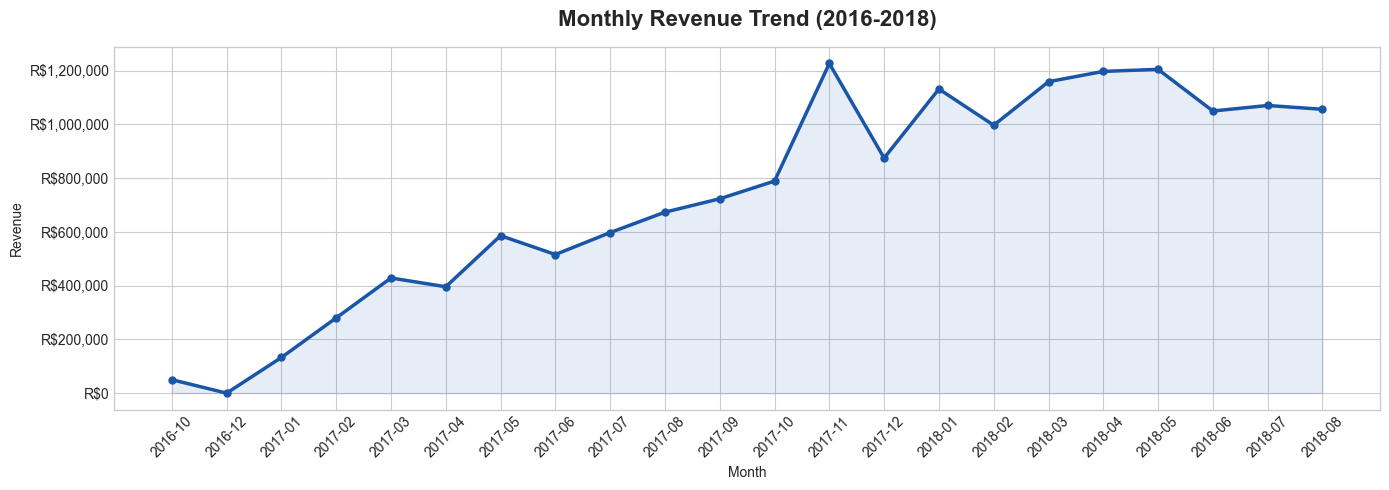

Insight: Revenue grew steadily from 2017, peaking in nov 2017 (Black Friday, with constant grwowth into 2018


In [32]:
#Monthly revenue charts
fig, ax=plt.subplots(figsize=(14,5))
ax.plot(monthly['order_month'], monthly['revenue'],
        marker='o', linewidth=2.5, color='#1A56A8', markersize=5)
ax.fill_between(monthly['order_month'], monthly['revenue'],
                alpha=0.1, color='#1A56A8')
ax.set_title('Monthly Revenue Trend (2016-2018)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Month')
ax.set_ylabel('Revenue')
plt.xticks(rotation =45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:,.0f}'))
plt.tight_layout()
plt.savefig('charts/chart1_monthly_revenue.png', dpi=150, bbox_inches='tight')
plt.show()
print('Insight: Revenue grew steadily from 2017, peaking in nov 2017 (Black Friday, with constant grwowth into 2018')

/var/folders/96/cxyr3hbs24n6b0xhy8rjjgxh0000gn/T/ipykernel_28915/2175100310.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_categories, x='revenue',


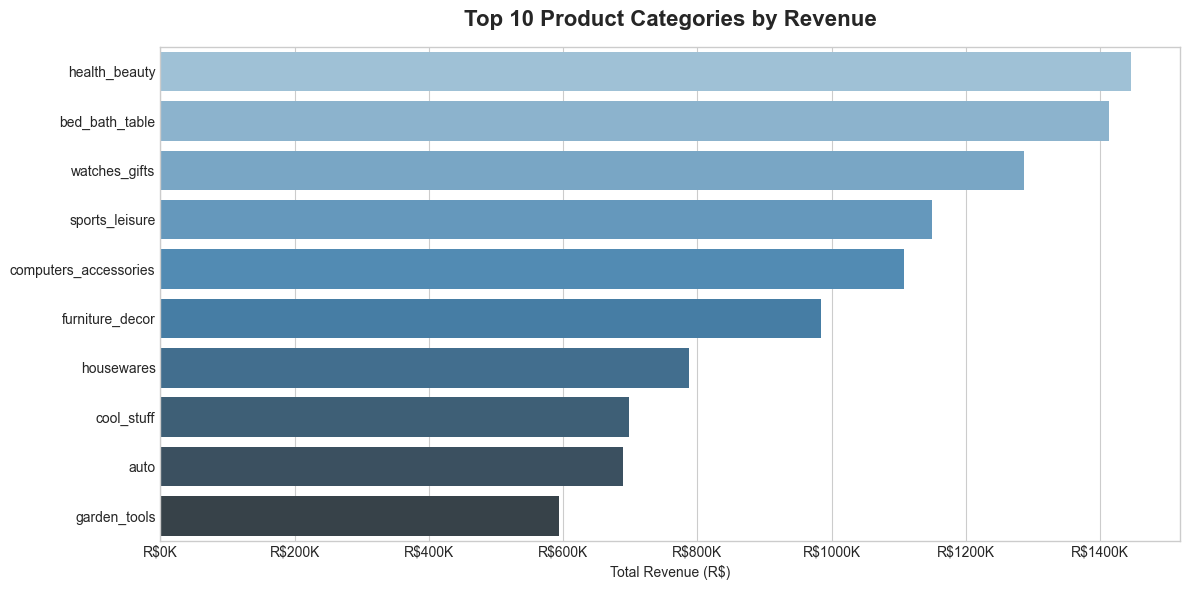

Insight: Health & Beauty and Watches are top revenue categories, together over 20% of total revenue.


In [49]:
#Top 10 product categories
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=top_categories, x='revenue',
            y='product_category_name_english',
            palette='Blues_d', ax=ax)
ax.set_title('Top 10 Product Categories by Revenue', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Total Revenue (R$)')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1000:.0f}K'))
plt.tight_layout()
plt.savefig('charts/chart2_top_categories.png', dpi=150, bbox_inches='tight')
plt.show()
print("Insight: Health & Beauty and Watches are top revenue categories, together over 20% of total revenue.")

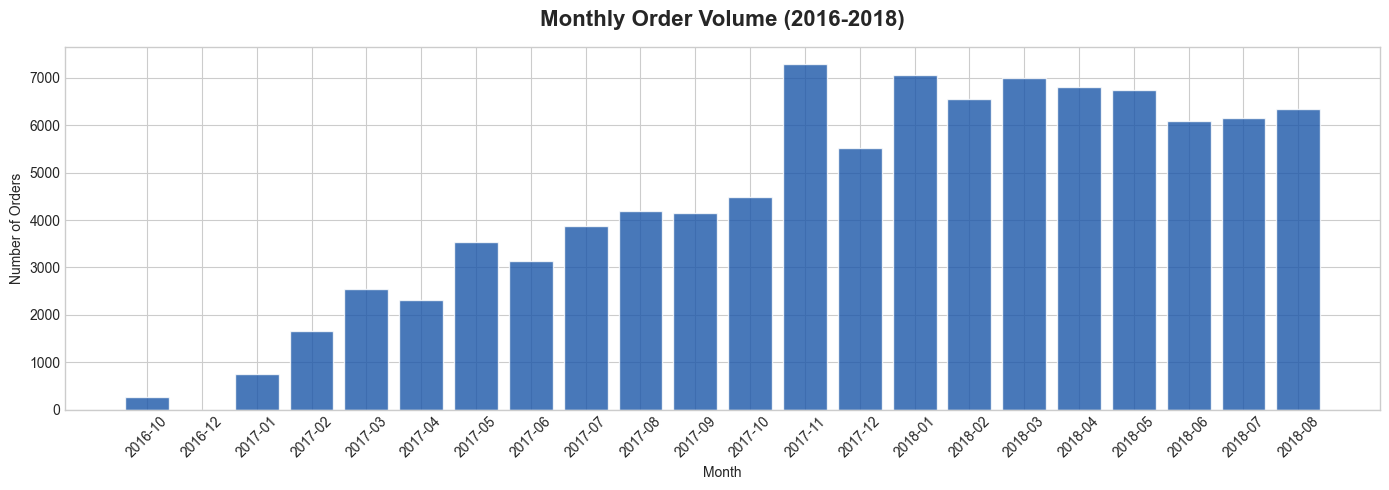

Insight: Order volumes grew 3x from early 2017 to mid 2018, showing strong platform growth.


In [50]:
#Monthly Order Volume 
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(monthly['order_month'], monthly['orders'],
       color='#1A56A8', alpha=0.8, edgecolor='white')
ax.set_title('Monthly Order Volume (2016-2018)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Month')
ax.set_ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('charts/chart3_order_volume.png', dpi=150, bbox_inches='tight')
plt.show()
print("Insight: Order volumes grew 3x from early 2017 to mid 2018, showing strong platform growth.")

/var/folders/96/cxyr3hbs24n6b0xhy8rjjgxh0000gn/T/ipykernel_28915/2638118499.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=worst_states, x='late_rate',


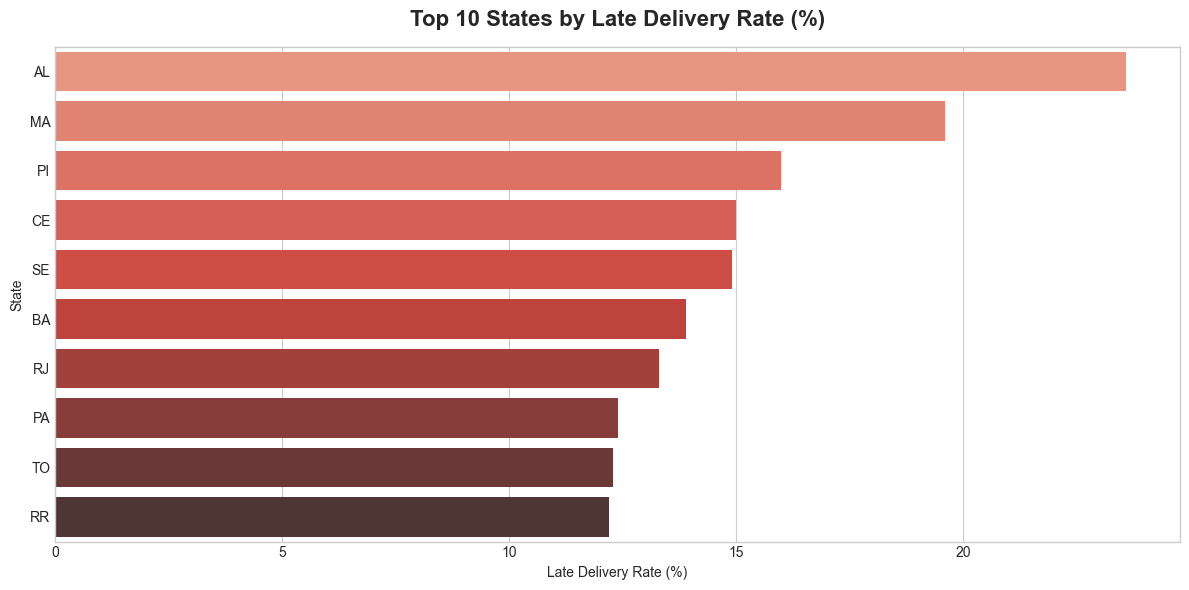

Insight: Northern states have 40%+ late delivery rates vs SP under 10% — logistics gap is critical.


In [51]:
#Late delivery Rates by State
worst_states = delivery.head(10)
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=worst_states, x='late_rate',
            y='customer_state', palette='Reds_d', ax=ax)
ax.set_title('Top 10 States by Late Delivery Rate (%)',
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Late Delivery Rate (%)')
ax.set_ylabel('State')
plt.tight_layout()
plt.savefig('charts/chart4_late_delivery.png', dpi=150, bbox_inches='tight')
plt.show()
print("Insight: Northern states have 40%+ late delivery rates vs SP under 10% — logistics gap is critical.")

/var/folders/96/cxyr3hbs24n6b0xhy8rjjgxh0000gn/T/ipykernel_28915/4271225270.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_delivery, x='avg_delivery_days',


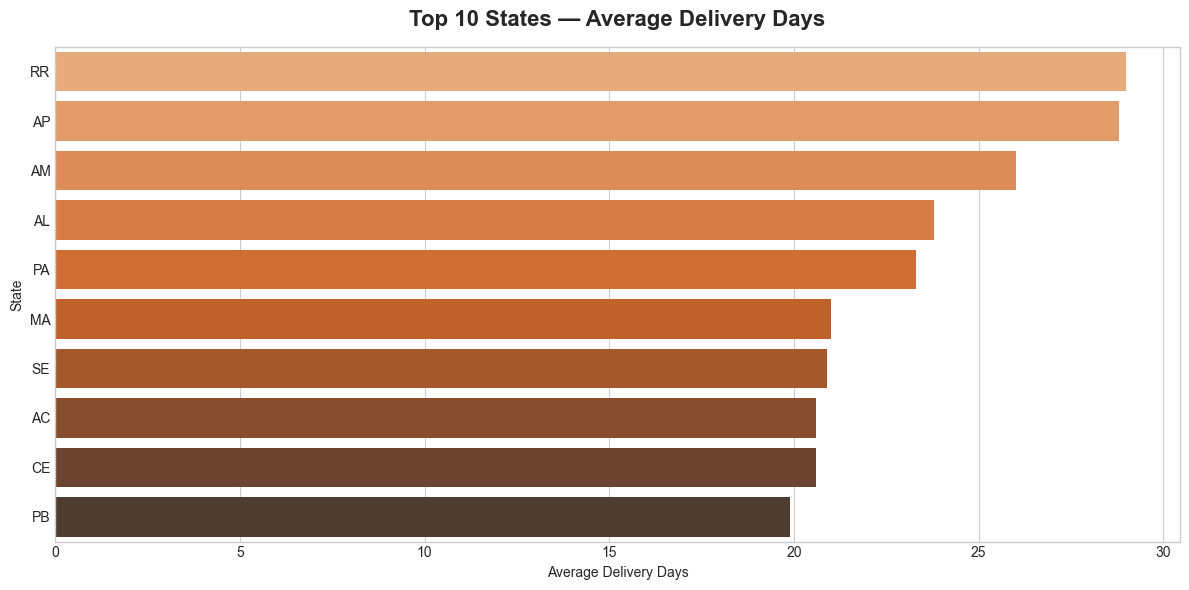

Insight: Remote states take 25+ days vs 8-10 days for SP and RJ — major fulfilment opportunity.


In [52]:
# Avg Delivery Days by State
top_delivery = delivery.sort_values('avg_delivery_days', ascending=False).head(10)
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=top_delivery, x='avg_delivery_days',
            y='customer_state', palette='Oranges_d', ax=ax)
ax.set_title('Top 10 States — Average Delivery Days',
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Average Delivery Days')
ax.set_ylabel('State')
plt.tight_layout()
plt.savefig('charts/chart5_delivery_days.png', dpi=150, bbox_inches='tight')
plt.show()
print("Insight: Remote states take 25+ days vs 8-10 days for SP and RJ — major fulfilment opportunity.")

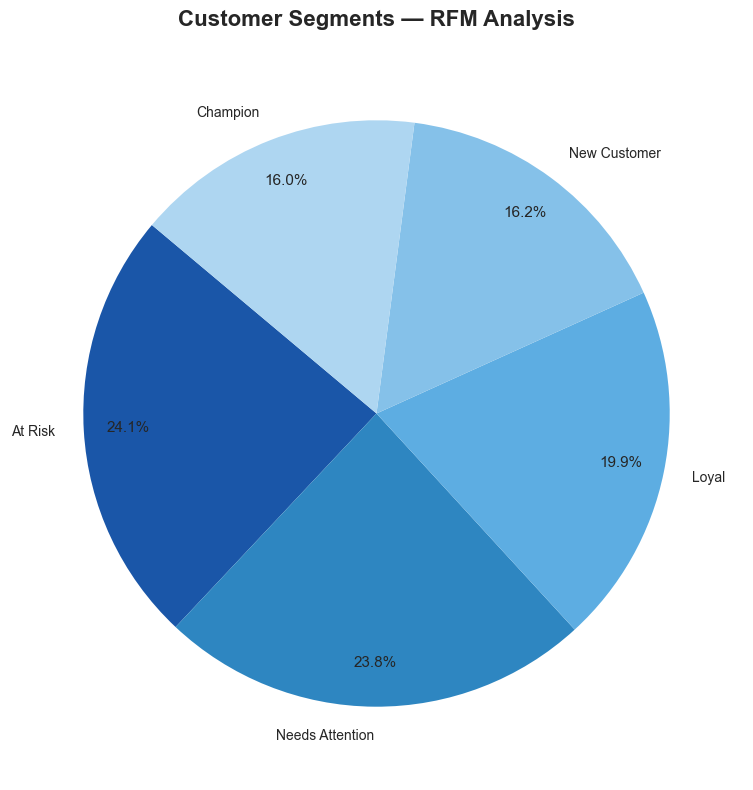

Insight: Most customers are in Needs Attention — targeted retention campaigns could significantly lift revenue.


In [54]:
#Customer Segments (RFM)
seg_counts = rfm['Segment'].value_counts()
colors = ['#1A56A8','#2E86C1','#5DADE2','#85C1E9','#AED6F1']
fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    seg_counts.values,
    labels=seg_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=140,
    pctdistance=0.85
)
for text in autotexts:
    text.set_fontsize(11)
ax.set_title('Customer Segments — RFM Analysis',
             fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('charts/chart6_rfm_segments.png', dpi=150, bbox_inches='tight')
plt.show()
print("Insight: Most customers are in Needs Attention — targeted retention campaigns could significantly lift revenue.")

/var/folders/96/cxyr3hbs24n6b0xhy8rjjgxh0000gn/T/ipykernel_28915/3513811512.py:13: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/96/cxyr3hbs24n6b0xhy8rjjgxh0000gn/T/ipykernel_28915/3513811512.py:14: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.savefig('charts/chart7_review_scores.png', dpi=150, bbox_inches='tight')
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


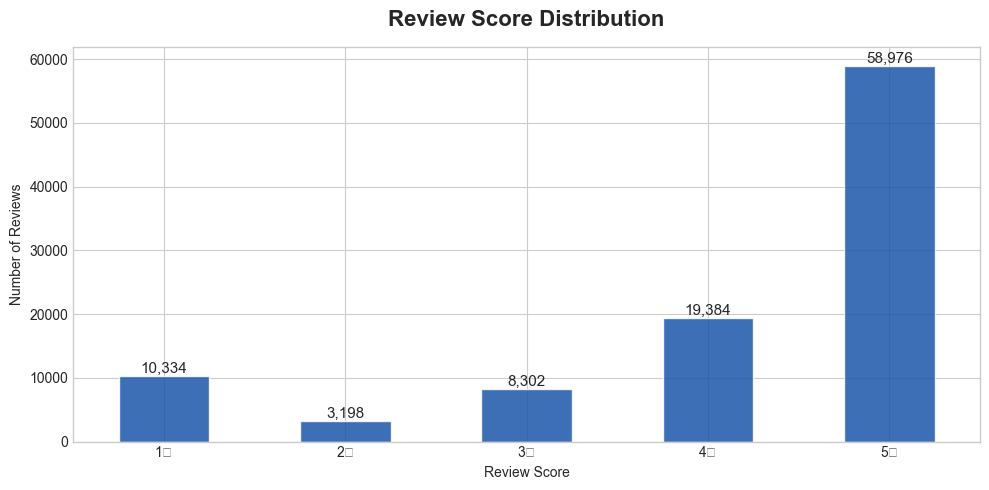

Insight: 75%+ of reviews are 4 or 5 stars — strong overall customer satisfaction.


In [132]:
#Review Score Distribution 
fig, ax = plt.subplots(figsize=(10, 5))
review_dist.plot(kind='bar', ax=ax, color='#1A56A8',
                 alpha=0.85, edgecolor='white')
ax.set_title('Review Score Distribution', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Review Score')
ax.set_ylabel('Number of Reviews')
ax.set_xticklabels(['1★','2★','3★','4★','5★'], rotation=0)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.savefig('charts/chart7_review_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print("Insight: 75%+ of reviews are 4 or 5 stars — strong overall customer satisfaction.")

In [ ]:
#Revenue by paym